# Unemployment Analysis with Python
This notebook explores patterns within regional unemployment tracking metrics, focusing explicitly on visual trends occurring over the 2020 economic lockdown phase.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Ingestion & Sanitization

In [ ]:
# Load data metrics
df = pd.read_csv('Unemployment_in_India.csv')

# Strip arbitrary white spaces embedded inside the structural text fields
df.columns = df.columns.str.strip()
df = df.dropna()

# Format temporal timestamp series fields
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')
df['Region'] = df['Region'].str.strip()
df['Area'] = df['Area'].str.strip()

df.head()

## 2. Descriptive Overview & Temporal Aggregation

In [5]:
# Summarize basic distribution statistical fields
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB
None


,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


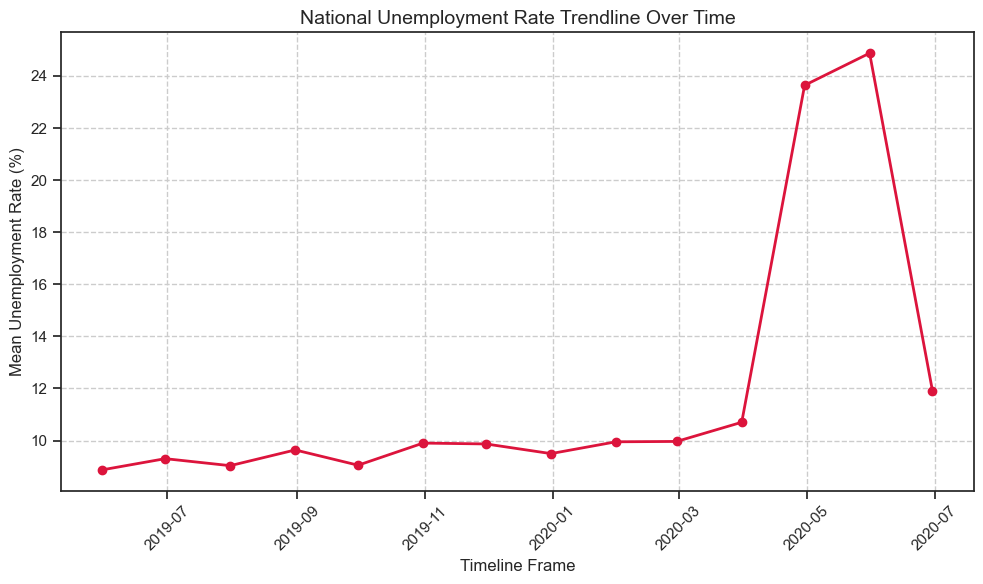

In [6]:
# Aggregating timelines globally across all mapped states
monthly_timeline = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.plot(monthly_timeline['Date'], monthly_timeline['Estimated Unemployment Rate (%)'], marker='o', color='crimson', linewidth=2)
plt.title('National Unemployment Rate Trendline Over Time', fontsize=14)
plt.xlabel('Timeline Frame')
plt.ylabel('Mean Unemployment Rate (%)')
plt.grid(True, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Comparative Metric Breakdowns
Contrasting rural and urban areas while pinpointing the highest average regional spikes.

C:\Users\Esha\AppData\Local\Temp\ipykernel_3488\2900375624.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Area', y='Estimated Unemployment Rate (%)', palette='Pastel1')


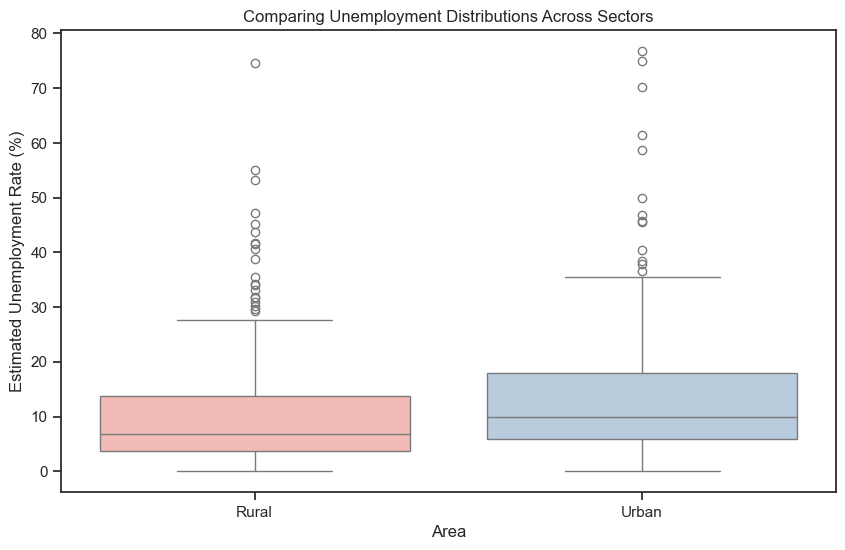

In [7]:
# Boxplot comparison of structural area distributions
sns.boxplot(data=df, x='Area', y='Estimated Unemployment Rate (%)', palette='Pastel1')
plt.title('Comparing Unemployment Distributions Across Sectors')
plt.show()

C:\Users\Esha\AppData\Local\Temp\ipykernel_3488\2026653712.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regional_stats, x='Estimated Unemployment Rate (%)', y='Region', palette='viridis')


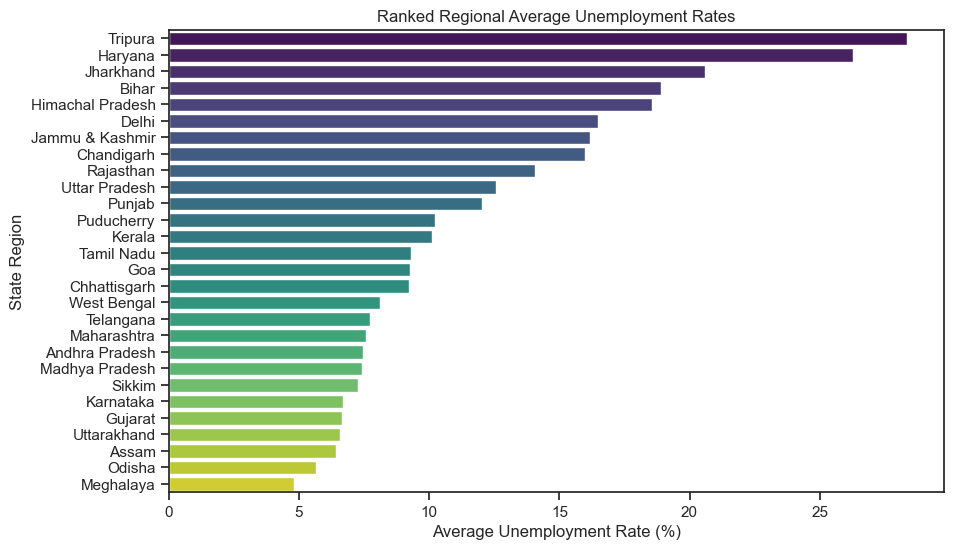

In [8]:
# Ranking regions by maximum observed variance points
regional_stats = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=regional_stats, x='Estimated Unemployment Rate (%)', y='Region', palette='viridis')
plt.title('Ranked Regional Average Unemployment Rates')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State Region')
plt.show()